# Ultralytics YOLO Lab: Performance + Resource Utilization (CPU/GPU)  

## What you'll produce
- A **results table** with one row per model 
- **Time-series logs** (optional) for CPU/RAM (and GPU if applicable)
- Exported CSVs with metrics for each model run

---

## Mind map of this notebook

**1) Setup**
- install/import
- choose OS + input mode (webcam / video)

**2) System Specs**
- auto-detect what we can (CPU, RAM, GPU)
- OS-specific commands for cache sizes (L1/L2)
- manual fill-ins where the OS doesn't expose cleanly

**3) Run Models**
- same input settings per model
- warmup -> measure (fair comparison)

**4) Record Metrics**
- image size (shape)
- ms/frame (mean)
- CPU load for *your process*
- RAM for *your process*
- GPU load for *your process* (if any)

**5) Export**
- `results_summary.csv` (spreadsheet-ready)
- `results_timeseries.csv` (optional deeper analysis)

---

## State machine (per model run)
**CONFIG -> WARMUP -> MEASURE -> SUMMARIZE -> APPEND ROW**

## 1) Environment setup

In [23]:
# If needed:
!pip -q install ultralytics psutil pandas tqdm opencv-python

import os, sys, time, platform, subprocess, re
import psutil
import pandas as pd
import numpy as np
import gc
from tqdm import tqdm
from typing import Optional
import cv2
from ultralytics import YOLO

## 2) Configuration (edit these first)

In [4]:
# =========================
# USER INPUTS
# =========================

YOUR_NAME = "[author]" 

# Choose your OS so the notebook can run the right commands:
# options: "windows", "mac", "linux"
OS_NAME = "windows"

# Input mode
# options: "webcam" or "video" for the source type. webcame for live inference and video for offline sequences
INPUT_MODE = "webcam"
WEBCAM_INDEX = 0 #cv2.videocapture(0), 1 for second cam, etc.
VIDEO_PATH = "video.mp4"

# Benchmark settings
IMGSZ = 640 #input resolution for square resize, ex: 640x640
#higher image size ups accuracy, computational cost, decreases FPS
CONF = 0.25
#confidence interval. if person: 0.91 and toothbrush: 0.18, toothbrush is not kept
#higher interval less detections but more conservative
IOU = 0.5
#Non-Maximum Suppression (NMS) IoU threshold.
#When multiple boxes overlap the same object:
#If overlap (IoU) > 0.5, then suppress the lower-confidence box.

WARMUP_SECONDS = 3.0
BENCH_SECONDS = 15.0
SAMPLE_METRICS_EVERY_S = 0.5

# Lab models
# Notes:
# - YOLOv8 "n" model weight is typically "yolov8n.pt"
# - YOLO26 models are "yolo26n.pt", etc. per Ultralytics docs.
# - YOLO-World v2 examples use names like "yolov8x-worldv2.pt"
LAB_MODELS = [
    {"lab_name": "yolo8n",          "weights": ["yolo8n.pt", "yolov8n.pt"]},
    {"lab_name": "yolo26n",         "weights": ["yolo26n.pt"]},
    {"lab_name": "yolo26x",         "weights": ["yolo26x.pt"]},
    {"lab_name": "yolo26n-seg",     "weights": ["yolo26n-seg.pt"]},
    {"lab_name": "yolo26n-pose",    "weights": ["yolo26n-pose.pt"]},
    # Optional:
    {"lab_name": "yolo8x-worldv2",  "weights": ["yolo8x-worldv2.pt", "yolov8x-worldv2.pt"], "optional": True},
]

# Include optional models?
INCLUDE_OPTIONAL_MODELS = False

#Do you want a live preview window during runs? (press 'q' to abort)
SHOW_PREVIEW = False

# Where to write outputs
OUT_DIR = "comp_vision_lab_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

#Derived: source for Ultralytics
SOURCE = WEBCAM_INDEX if INPUT_MODE.lower() == "webcam" else VIDEO_PATH

print("SOURCE =", SOURCE)

SOURCE = 0


## 3) System specs collection (auto + OS-specific)

In [5]:
def _run_cmd(cmd: str) -> str:
    #Why we wrap system calls:
    #In benchmarking, reproducibility matters. Instead of manually asking students
    #to look up specs, we programmatically query the OS so results are consistent.
    #This function abstracts OS shell access into a safe, reusable helper.

    try:
        #Why subprocess:
        #We need access to low-level hardware metadata (CPU model, cache sizes, GPU).
        #Python itself does not expose detailed hardware info directly,
        #so we call native OS tools (wmic, sysctl, lscpu, etc.).
        out = subprocess.check_output(cmd, shell=True, stderr=subprocess.STDOUT, text=True)

        #OS commands often return trailing newline characters.
        #Stripping ensures clean parsing and consistent string comparisons.
        return out.strip()

    except Exception as e:
        #Why explicit error return:
        #Hardware reporting varies across systems.
        #Instead of crashing the notebook (bad for a lab handout),
        #we return an error string so students can override manually.
        return f"ERROR: {e}"


def detect_make_model(os_name: str):
    #Why detect system make/model:
    #In performance benchmarking, hardware context is critical

    osn = os_name.lower()
    make, model = None, None

    if osn == "windows":
    #Registry is the most reliable source for manufacturer/model on modern Windows
    #because WMIC is deprecated and PowerShell CIM can be missing/blocked.
        manu = _run_cmd(r'reg query "HKLM\HARDWARE\DESCRIPTION\System\BIOS" /v SystemManufacturer')
        prod = _run_cmd(r'reg query "HKLM\HARDWARE\DESCRIPTION\System\BIOS" /v SystemProductName')

        m1 = re.search(r"SystemManufacturer\s+REG_\w+\s+(.*)", manu)
        m2 = re.search(r"SystemProductName\s+REG_\w+\s+(.*)", prod)

        make = m1.group(1).strip() if m1 else None
        model = m2.group(1).strip() if m2 else None

    elif osn == "mac":
        #Why sysctl:macOS exposes hardware metadata through sysctl.
        #hw.model gives the machine identifier (e.g., MacBookPro18,3).
        txt = _run_cmd("sysctl -n hw.model")
        model = txt if "ERROR" not in txt else None

        #Apple hardware always reports as Apple,
        #so we standardize manufacturer labeling.
        make = "Apple"

    elif osn == "linux":
        #Why hostnamectl: Linux distributions vary widely.
        #hostnamectl aggregates hardware metadata in a consistent way across many distros.
        txt = _run_cmd("hostnamectl")

        m1 = re.search(r"Hardware Vendor:\s*(.*)", txt)
        m2 = re.search(r"Hardware Model:\s*(.*)", txt)

        make = m1.group(1).strip() if m1 else None
        model = m2.group(1).strip() if m2 else None

    return make, model


def detect_cpu_model(os_name: str):
    #Why exact CPU string matters:
    #YOLO inference speed is heavily CPU-bound in your experiment.
    #Clock speed, architecture generation, core count, and cache design
    #all affect throughput. We record the exact CPU model for fairness.

    osn = os_name.lower()

    if osn == "windows":
        if osn == "windows":
            #platform.processor() often returns a generic family string on Windows
            #Registry contains the exact marketing name.
            txt = _run_cmd(r'reg query "HKLM\HARDWARE\DESCRIPTION\System\CentralProcessor\0" /v ProcessorNameString')
            m = re.search(r"ProcessorNameString\s+REG_\w+\s+(.*)", txt)
            return m.group(1).strip() if m else platform.processor()

    elif osn == "mac":
        #Why machdep.cpu.brand_string:
        #This returns the full marketing CPU name (e.g., Apple M2, Intel i7-9750H).
        txt = _run_cmd("sysctl -n machdep.cpu.brand_string")
        return txt if "ERROR" not in txt else platform.processor()

    else:
        #Why lscpu on Linux:
        #lscpu aggregates detailed CPU architecture info.
        txt = _run_cmd("lscpu")
        m = re.search(r"Model name:\s*(.*)", txt)
        return m.group(1).strip() if m else platform.processor()


def detect_cache_sizes(os_name: str):
    #Why cache sizes matter in CV:
    #Deep learning inference involves repeated tensor operations.
    #L1/L2 cache size influences how efficiently matrix multiplications
    #and convolution kernels stay near the CPU core.
    #Larger caches often reduce memory stalls -> better throughput.

    osn = os_name.lower()
    L1, L2 = None, None

    if osn == "windows":
        L1 = "Unknown (Windows often does not expose L1 via standard APIs)"

        #Try Win32_Processor first
        txt = _run_cmd(
            'powershell -NoProfile -Command '
            '"(Get-WmiObject Win32_Processor | Select-Object -First 1 -ExpandProperty L2CacheSize)"'
        )
        t = txt.strip() if "ERROR" not in txt else ""
        if t.isdigit():
            kb = float(t)
            L2 = f"{kb/1024:.2f} MB"
            return L1, L2

        #Fallback: Get-ComputerInfo (sometimes exposes cache fields differently)
        txt2 = _run_cmd(
            'powershell -NoProfile -Command '
            '"(Get-ComputerInfo | Select-Object -ExpandProperty CsProcessors)"'
        )
        #If fallback doesn't help, leave L2 as None and rely on manual override

    elif osn == "mac":
        #Why separate L1d and L1i:
        #Modern CPUs separate data cache and instruction cache.
        #This can affect inference performance differently.
        l1d = _run_cmd("sysctl -n hw.l1dcachesize")
        l1i = _run_cmd("sysctl -n hw.l1icachesize")
        l2  = _run_cmd("sysctl -n hw.l2cachesize")

        def fmt_bytes(x):
            try:
                b = float(x)
                #Why conditional formatting:
                #Keeps output human-readable across KB/MB scales.
                return f"{b/1024:.0f} KB" if b < 1024**2 else f"{b/1024**2:.2f} MB"
            except:
                return None

        L1 = f"L1d={fmt_bytes(l1d)}, L1i={fmt_bytes(l1i)}" if "ERROR" not in l1d and "ERROR" not in l1i else None
        L2 = fmt_bytes(l2) if "ERROR" not in l2 else None

    else:
        #Why Linux lscpu:
        #Linux exposes detailed cache hierarchy cleanly.
        txt = _run_cmd("lscpu")

        m1 = re.search(r"L1d cache:\s*(.*)", txt)
        m2 = re.search(r"L1i cache:\s*(.*)", txt)
        m3 = re.search(r"L2 cache:\s*(.*)", txt)

        if m1 or m2:
            L1 = f"L1d={m1.group(1).strip() if m1 else '?'}, L1i={m2.group(1).strip() if m2 else '?'}"
        L2 = m3.group(1).strip() if m3 else None

    return L1, L2


def detect_gpu(os_name: str):
    #Why GPU detection:
    #Even if running CPU-only, documenting GPU presence matters.
    #A discrete GPU changes thermal behavior, memory bandwidth,
    #and potentially background system scheduling.

    osn = os_name.lower()

    if osn == "windows":
        #Get-CimInstance can fail depending on PowerShell version/policies
        #Get-WmiObject is older but usually works in classroom Windows setups.
        txt = _run_cmd(
            'powershell -NoProfile -Command '
            '"Get-WmiObject Win32_VideoController | Select-Object -ExpandProperty Name"'
        )
        if "ERROR" in txt:
            return None
        lines = [l.strip() for l in txt.splitlines() if l.strip()]
        return ", ".join(lines) if lines else None

    elif osn == "mac":
        #Why system_profiler:
        #macOS hides GPU details behind system_profiler.
        txt = _run_cmd("system_profiler SPDisplaysDataType")
        m = re.findall(r"Chipset Model:\s*(.*)", txt)
        return ", ".join([x.strip() for x in m]) if m else None

    else:
        #Why lspci:
        #On Linux, GPUs appear as VGA/3D controllers in PCI listing.
        txt = _run_cmd(r"lspci | grep -i 'vga\|3d\|2d'")
        return txt if "ERROR" not in txt else None


#Why gather specs before running models:
#This ensures every performance row includes hardware context,
#which is essential for reproducible and comparable benchmarking.

MAKE, MODEL = detect_make_model(OS_NAME)
CPU_MODEL = detect_cpu_model(OS_NAME)
L1_SIZE, L2_SIZE = detect_cache_sizes(OS_NAME)
GPU_MODEL = detect_gpu(OS_NAME)

#Why total system RAM:
#This is the "memory size per specs" required by the lab.
#Total RAM influences memory pressure and paging during inference.
TOTAL_MEM_GB = psutil.virtual_memory().total / (1024**3)

SYSTEM_SPECS = {
    "make": MAKE,
    "model": MODEL,
    "cpu": CPU_MODEL,
    "l1": L1_SIZE,
    "l2": L2_SIZE,
    "gpu": GPU_MODEL,
    "mem_specs_gb": round(TOTAL_MEM_GB, 2),
}
SYSTEM_SPECS

{'make': 'HP',
 'model': 'HP Envy x360 2-in-1 Laptop 16-ad0xxx',
 'cpu': 'AMD Ryzen 7 8840HS w/ Radeon 780M Graphics',
 'l1': 'Unknown (Windows often does not expose L1 via standard APIs)',
 'l2': None,
 'gpu': None,
 'mem_specs_gb': 15.3}

### Manual spec overrides (recommended)

Auto-detection isn't perfect (especially L1 on Windows).  
If any field above is wrong/blank, edit the values below.

In [6]:
# You can override any fields here:
MAKE_OVERRIDE = ""       # e.g., "Dell"
MODEL_OVERRIDE = ""      # e.g., "XPS 15 9520"
CPU_OVERRIDE = ""        # e.g., "Intel i5-12400F"
L1_OVERRIDE = "512KB"         # e.g., "1.25 MB" or "L1d=..., L1i=..."
L2_OVERRIDE = "8MB"         # e.g., "12 MB"
GPU_OVERRIDE = ""        # e.g., "Intel UHD (integrated)" or "RTX 4060 (discrete)"
USING_GPU = "No"         # Yes / No / Unsure

def merged_specs():
    return {
        "make": MAKE_OVERRIDE or SYSTEM_SPECS.get("make"),
        "model": MODEL_OVERRIDE or SYSTEM_SPECS.get("model"),
        "cpu": CPU_OVERRIDE or SYSTEM_SPECS.get("cpu"),
        "l1": L1_OVERRIDE or SYSTEM_SPECS.get("l1"),
        "l2": L2_OVERRIDE or SYSTEM_SPECS.get("l2"),
        "gpu": GPU_OVERRIDE or SYSTEM_SPECS.get("gpu"),
        "using_gpu": USING_GPU,
        "mem_specs_gb": SYSTEM_SPECS.get("mem_specs_gb"),
    }

merged_specs()

{'make': 'HP',
 'model': 'HP Envy x360 2-in-1 Laptop 16-ad0xxx',
 'cpu': 'AMD Ryzen 7 8840HS w/ Radeon 780M Graphics',
 'l1': '512KB',
 'l2': '8MB',
 'gpu': None,
 'using_gpu': 'No',
 'mem_specs_gb': 15.3}

## 5) Benchmark runner (webcam or video)

In [7]:
#=========================
#RUNNER(STATE:WARMUP→MEASURE→SUMMARIZE)
#=========================
#Why this runner exists:
#We need a fair, repeatable way to compare YOLO model sizes on the same input.
#We separate WARMUP(one-time overhead) from MEASURE(steady-state inference).
#We sample CPU/RAM on a fixed cadence so logging overhead is consistent across models.

def pick_weights(candidates):
    #Why weight name fallback:
    #Ultralytics weight naming differs across model families (e.g., yolo8n vs yolov8n).
    #We try multiple names so the lab handout can work for more setups
    last_err = None
    for w in candidates:
        try:
            _ = YOLO(w)
            return w
        except Exception as e:
            last_err = e
    raise RuntimeError(f"Could not load any weights from {candidates}. Last error: {last_err}")

def get_first_frame_shape(source):
    #Why log image shape:
    #Input resolution changes compute cost and detection behavior.
    #We record (H,W,C) to make results interpretable and comparable.
    cap = cv2.VideoCapture(source)
    ok, frame = cap.read()
    cap.release()
    if not ok or frame is None:
        return None
    return frame.shape  # (H,W,C)

def run_model_once(lab_name, weight_name, source, task="predict"):
    #Why own the capture:
    #Ultralytics stream=True may keep the camera handle open in a loader thread.
    #If we open cv2.VideoCapture ourselves, we can ALWAYS cap.release() at the end.
    model = YOLO(weight_name)

    proc = psutil.Process()
    proc.cpu_percent(interval=None)
    psutil.cpu_percent(interval=None)

    #Why CAP_DSHOW on Windows:
    #DirectShow tends to release webcams more reliably than default backends on Windows.
    #If you're not on Windows, OpenCV will ignore it or you can remove it.
    is_webcam = (source == 0) or (source == "0")
    if is_webcam:
        cap = cv2.VideoCapture(int(source), cv2.CAP_DSHOW)
    else:
        cap = cv2.VideoCapture(source)

    if not cap.isOpened():
        raise RuntimeError("Could not open video source. Check webcam index or VIDEO_PATH.")

    #Why timing windows:
    #We ignore warmup seconds and only measure steady-state.
    t0 = time.perf_counter()
    warmup_end = t0 + float(WARMUP_SECONDS)
    end_t = warmup_end + float(BENCH_SECONDS)

    frame_times = []
    ts_rows = []
    next_sample_t = t0
    t_last = t0

    aborted = False

    try:
        while True:
            now = time.perf_counter()
            if now >= end_t:
                break

            ok, frame = cap.read()
            if not ok or frame is None:
                #Why break on end-of-stream:
                #For videos, this means file ended.
                break

            #Why fixed cadence metrics:
            #Avoids metric logging overhead scaling with FPS.
            if now >= next_sample_t:
                ts_rows.append({
                    "t_perf": now,
                    "lab_model": lab_name,
                    "weights": weight_name,
                    "phase": "warmup" if now < warmup_end else "measure",
                    "proc_cpu_pct": proc.cpu_percent(interval=None),
                    "proc_rss_gb": proc.memory_info().rss / (1024**3),
                    "sys_cpu_pct": psutil.cpu_percent(interval=None),
                    "sys_ram_pct": psutil.virtual_memory().percent,
                    "cpu_freq_mhz": (psutil.cpu_freq().current if psutil.cpu_freq() else None),
                })
                next_sample_t = now + float(SAMPLE_METRICS_EVERY_S)

            #Why call YOLO on frames:
            #This avoids Ultralytics opening the webcam internally.
            #track/predict both accept numpy frames as "source".
            if task == "track":
                res = model.track(source=frame, persist=True, imgsz=IMGSZ, conf=CONF, iou=IOU, verbose=False)
            elif task == "predict":
                res = model.predict(source=frame, imgsz=IMGSZ, conf=CONF, iou=IOU, verbose=False)
            else:
                raise ValueError("task must be 'track' or 'predict'")

            #Why exclude warmup from timing:
            #Warmup includes one-time allocations/caches and biases ms/frame.
            if now >= warmup_end:
                dt = now - t_last
                frame_times.append(dt)
            t_last = now

            #Optional preview:
            if SHOW_PREVIEW and res is not None and len(res) > 0:
                try:
                    vis = res[0].plot()
                    cv2.imshow(f"{lab_name} ({weight_name})", vis)
                    if cv2.waitKey(1) & 0xFF == ord('q'):
                        aborted = True
                        break
                except Exception:
                    pass

    finally:
        #Why finally:
        #Guarantees the webcam is released even if errors occur mid-run.
        cap.release()
        try:
            cv2.destroyAllWindows()
        except Exception:
            pass

    if aborted:
        print("Aborted by user (q).")

    if len(frame_times) == 0:
        raise RuntimeError("No measured frames. Check source or increase BENCH_SECONDS.")

    avg_dt = sum(frame_times) / len(frame_times)
    ms_per_frame = avg_dt * 1000.0

    ts_df = pd.DataFrame(ts_rows)
    ts_measure = ts_df[ts_df["phase"] == "measure"] if len(ts_df) else ts_df

    cpu_proc_avg = float(ts_measure["proc_cpu_pct"].mean()) if len(ts_measure) else None
    mem_proc_avg = float(ts_measure["proc_rss_gb"].mean()) if len(ts_measure) else None

    #Why image size:
    #Frame shape is part of the experiment condition.
    img_shape_str = str(frame.shape) if "frame" in locals() and frame is not None else ""

    row = merged_specs()
    row.update({
        "your_name": YOUR_NAME,
        "image_size": img_shape_str,
        "yolo_model": lab_name,
        "weights_used": weight_name,
        "mem_size_gb_specs": row["mem_specs_gb"],
        "mem_size_gb_task_manager": None,
        "mem_size_gb_process": round(mem_proc_avg, 3) if mem_proc_avg is not None else None,
        "time_ms_per_frame": round(ms_per_frame, 2),
        "cpu_load_proc_pct": round(cpu_proc_avg, 2) if cpu_proc_avg is not None else None,
        "gpu_load_proc_pct": 0.0 if str(row["using_gpu"]).lower() == "no" else None,
    })

    return row, ts_df

## 6) Run the lab experiment (one row per model)

In [8]:
models_to_run = []
for m in LAB_MODELS:
    if m.get("optional") and not INCLUDE_OPTIONAL_MODELS:
        continue
    models_to_run.append(m)

results = []
ts_all = []

for m in models_to_run:
    lab_name = m["lab_name"]
    weight = pick_weights(m["weights"])
    print(f"\n=== Running {lab_name} using {weight} ===")
    row, ts_df = run_model_once(lab_name, weight, SOURCE, task="predict")
    results.append(row)
    ts_all.append(ts_df)

df_results = pd.DataFrame(results)
df_ts = pd.concat(ts_all, ignore_index=True) if ts_all else pd.DataFrame()

display(df_results)
print("Time-series rows:", len(df_ts))


=== Running yolo8n using yolov8n.pt ===

=== Running yolo26n using yolo26n.pt ===

=== Running yolo26x using yolo26x.pt ===

=== Running yolo26n-seg using yolo26n-seg.pt ===

=== Running yolo26n-pose using yolo26n-pose.pt ===


,make,model,cpu,l1,l2,gpu,using_gpu,mem_specs_gb,your_name,image_size,yolo_model,weights_used,mem_size_gb_specs,mem_size_gb_task_manager,mem_size_gb_process,time_ms_per_frame,cpu_load_proc_pct,gpu_load_proc_pct
0,HP,HP Envy x360 2-in-1 Laptop 16-ad0xxx,AMD Ryzen 7 8840HS w/ Radeon 780M Graphics,512KB,8MB,None,No,15.3,[author],"(480, 640, 3)",yolo8n,yolov8n.pt,15.3,None,0.195,88.41,762.71,0.0
1,HP,HP Envy x360 2-in-1 Laptop 16-ad0xxx,AMD Ryzen 7 8840HS w/ Radeon 780M Graphics,512KB,8MB,None,No,15.3,[author],"(480, 640, 3)",yolo26n,yolo26n.pt,15.3,None,0.235,103.21,771.58,0.0
2,HP,HP Envy x360 2-in-1 Laptop 16-ad0xxx,AMD Ryzen 7 8840HS w/ Radeon 780M Graphics,512KB,8MB,None,No,15.3,[author],"(480, 640, 3)",yolo26x,yolo26x.pt,15.3,None,0.748,800.86,774.61,0.0
3,HP,HP Envy x360 2-in-1 Laptop 16-ad0xxx,AMD Ryzen 7 8840HS w/ Radeon 780M Graphics,512KB,8MB,None,No,15.3,[author],"(480, 640, 3)",yolo26n-seg,yolo26n-seg.pt,15.3,None,0.763,138.03,725.44,0.0
4,HP,HP Envy x360 2-in-1 Laptop 16-ad0xxx,AMD Ryzen 7 8840HS w/ Radeon 780M Graphics,512KB,8MB,None,No,15.3,[author],"(480, 640, 3)",yolo26n-pose,yolo26n-pose.pt,15.3,None,0.774,114.73,754.20,0.0


Time-series rows: 153


### Note on “Task Manager / Activity Monitor memory”

This template **does not rely on the Task Manager / Activity Monitor UI**.  
Instead, it logs **process memory directly** using `psutil` (RSS, in GB). This is generally *more reproducible* across OSes.

## 7) Export (spreadsheet-ready)

In [9]:
SPREADSHEET_COLUMNS = [
    "your_name",
    "make",
    "model",
    "cpu",
    "l1",
    "l2",
    "gpu",
    "using_gpu",
    "image_size",
    "yolo_model",
    "mem_size_gb_specs",
    "mem_size_gb_task_manager",
    "mem_size_gb_process",
    "time_ms_per_frame",
    "cpu_load_proc_pct",
    "gpu_load_proc_pct",
]

for c in SPREADSHEET_COLUMNS:
    if c not in df_results.columns:
        df_results[c] = None

df_out = df_results[SPREADSHEET_COLUMNS].copy()

summary_path = os.path.join(OUT_DIR, "results_summary.csv")
timeseries_path = os.path.join(OUT_DIR, "results_timeseries.csv")

df_out.to_csv(summary_path, index=False)
df_ts.to_csv(timeseries_path, index=False)

print("Saved:", summary_path)
print("Saved:", timeseries_path)

df_out

Saved: comp_vision_lab_outputs\results_summary.csv
Saved: comp_vision_lab_outputs\results_timeseries.csv


,your_name,make,model,cpu,l1,l2,gpu,using_gpu,image_size,yolo_model,mem_size_gb_specs,mem_size_gb_task_manager,mem_size_gb_process,time_ms_per_frame,cpu_load_proc_pct,gpu_load_proc_pct
0,[author],HP,HP Envy x360 2-in-1 Laptop 16-ad0xxx,AMD Ryzen 7 8840HS w/ Radeon 780M Graphics,512KB,8MB,None,No,"(480, 640, 3)",yolo8n,15.3,None,0.195,88.41,762.71,0.0
1,[author],HP,HP Envy x360 2-in-1 Laptop 16-ad0xxx,AMD Ryzen 7 8840HS w/ Radeon 780M Graphics,512KB,8MB,None,No,"(480, 640, 3)",yolo26n,15.3,None,0.235,103.21,771.58,0.0
2,[author],HP,HP Envy x360 2-in-1 Laptop 16-ad0xxx,AMD Ryzen 7 8840HS w/ Radeon 780M Graphics,512KB,8MB,None,No,"(480, 640, 3)",yolo26x,15.3,None,0.748,800.86,774.61,0.0
3,[author],HP,HP Envy x360 2-in-1 Laptop 16-ad0xxx,AMD Ryzen 7 8840HS w/ Radeon 780M Graphics,512KB,8MB,None,No,"(480, 640, 3)",yolo26n-seg,15.3,None,0.763,138.03,725.44,0.0
4,[author],HP,HP Envy x360 2-in-1 Laptop 16-ad0xxx,AMD Ryzen 7 8840HS w/ Radeon 780M Graphics,512KB,8MB,None,No,"(480, 640, 3)",yolo26n-pose,15.3,None,0.774,114.73,754.20,0.0


## 8) Quick plots (optional)

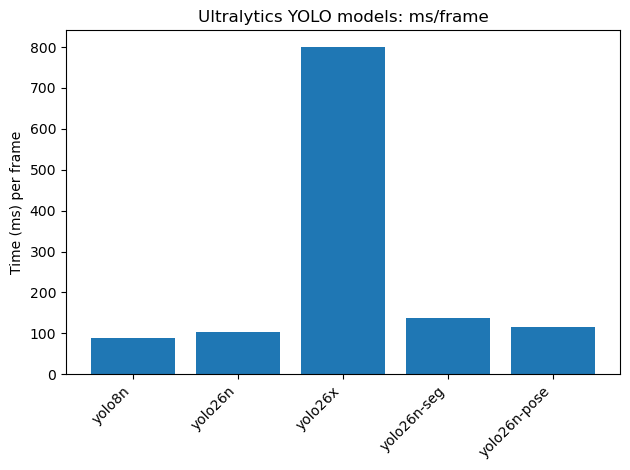

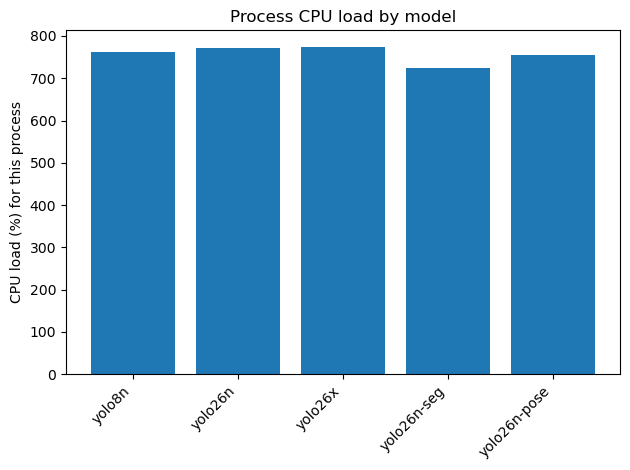

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(df_out["yolo_model"], df_out["time_ms_per_frame"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Time (ms) per frame")
plt.title("Ultralytics YOLO models: ms/frame")
plt.tight_layout()
plt.show()

plt.figure()
plt.bar(df_out["yolo_model"], df_out["cpu_load_proc_pct"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("CPU load (%) for this process")
plt.title("Process CPU load by model")
plt.tight_layout()
plt.show()

Reflection: As expected, the YOLO26x model exhibits significantly higher inference latency (~1000 ms/frame), reflecting its increased parameter count and computational complexity. Smaller models (YOLO8n, YOLO26n, YOLO26n-seg, YOLO26n-pose) exhibit similar latency values (~170–230 ms/frame), suggesting that CPU util loadt under CPU-only conditions at 640×640 resolution.

## Notes on optional experiment

- Students choose OS (`OS_NAME`) and input mode (`INPUT_MODE`)
- Hardware info is auto-collected + manually overridable
- Output CSV matches the lab spreadsheet columns
- Standardization knobs: `IMGSZ`, `BENCH_SECONDS`, `CONF`, `IOU`


---



## Semantic accuracy study (human-in-the-loop)

### Why this exists (mind-map)

**Goal:** test whether **semantic correctness** (did the model name the object correctly?) correlates with **model size**.

**Idea:** while running webcam/video inference we **sample a few detections**, save the **cropped boxes**, then **quiz a human** afterwards:
- model says: *toothbrush*
- you say: **no, it's a pen**
- we log that correction

This creates a lightweight **human-labeled dataset** on-the-fly, per model size, without needing a full benchmark dataset.

### State machine for this experiment

1. **RUN** (webcam/video) -> collect YOLO detections
2. **SAMPLE** some boxes -> save crops + metadata
3. **REVIEW** crops -> human confirms/corrects labels
4. **SCORE** per model -> accuracy + confusion-ish summaries
5. **COMPARE** accuracy vs FPS / latency across model sizes


### Install / imports (only needed for this section)

In [16]:
# If you don't have widgets already, uncomment:
# !pip -q install ipywidgets

import os, time
import pandas as pd

from IPython.display import display, clear_output
try:
    import ipywidgets as widgets
    _HAS_WIDGETS = True
except Exception:
    _HAS_WIDGETS = False

try:
    import cv2
    _HAS_CV2 = True
except Exception:
    _HAS_CV2 = False


### Capture settings

In [12]:
# === Capture configuration ===
CAPTURE_QUIZ_SAMPLES = True      # turn on/off sampling crops during a run
CAPTURE_DIR = "captures"         # folder where crops + metadata are written
CAPTURE_EVERY_SECONDS = 1.0      # sample at most once per X seconds
MAX_CAPTURES_PER_RUN = 120       # cap so you don't create thousands of crops
MIN_CONF_FOR_CAPTURE = 0.35      # ignore very low-confidence boxes

os.makedirs(CAPTURE_DIR, exist_ok=True)

### Helper: save crops from a YOLO result

In [13]:
def _xyxy_to_int(xyxy, w, h):
    x1, y1, x2, y2 = [int(round(float(v))) for v in xyxy]
    x1 = max(0, min(x1, w - 1))
    x2 = max(0, min(x2, w - 1))
    y1 = max(0, min(y1, h - 1))
    y2 = max(0, min(y2, h - 1))
    if x2 <= x1: x2 = min(w - 1, x1 + 1)
    if y2 <= y1: y2 = min(h - 1, y1 + 1)
    return x1, y1, x2, y2

def capture_crops_from_result(result, model_tag, run_tag, capture_dir=CAPTURE_DIR, min_conf=MIN_CONF_FOR_CAPTURE):
    '''
    Saves cropped detections from an Ultralytics result to disk + returns rows of metadata.

    Mind-map:
    - We want *semantic evaluation*, not perfect tracking evaluation.
    - So we sample a few boxes, save crops, and ask a human later.
    '''
    rows = []

    if result is None or result.boxes is None or len(result.boxes) == 0:
        return rows

    img = result.orig_img  # numpy BGR image
    if img is None:
        return rows

    h, w = img.shape[:2]

    boxes = result.boxes
    xyxy = boxes.xyxy.cpu().numpy()
    conf = boxes.conf.cpu().numpy()
    cls = boxes.cls.cpu().numpy().astype(int)

    # Track IDs may not exist depending on tracker/back-end
    track_ids = None
    if hasattr(boxes, "id") and boxes.id is not None:
        try:
            track_ids = boxes.id.cpu().numpy().astype(int)
        except Exception:
            track_ids = None

    names = result.names if hasattr(result, "names") else None

    ts = time.time()
    for i in range(len(xyxy)):
        if float(conf[i]) < float(min_conf):
            continue

        x1, y1, x2, y2 = _xyxy_to_int(xyxy[i], w, h)
        crop = img[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        pred_cls = int(cls[i])
        pred_name = names.get(pred_cls, str(pred_cls)) if isinstance(names, dict) else str(pred_cls)
        tid = int(track_ids[i]) if track_ids is not None else None

        fname = f"{model_tag}__{run_tag}__{int(ts*1000)}__i{i}__{pred_name}.jpg"
        fpath = os.path.join(capture_dir, fname)

        cv2.imwrite(fpath, crop)

        rows.append({
            "model": model_tag,
            "run": run_tag,
            "t": ts,
            "file": fpath,
            "pred_name": pred_name,
            "pred_cls": pred_cls,
            "conf": float(conf[i]),
            "track_id": tid,
            "x1": x1, "y1": y1, "x2": x2, "y2": y2,
            "frame_w": w, "frame_h": h,
        })

    return rows

### Hook: integrate crop capture into the benchmark runner

If you already ran benchmarks above, you can re-run with capture enabled. **This wrapper** opportunistically saves crops during the MEASURE window.

In [24]:
def run_benchmark_with_capture(
    model_path: str,
    source,
    task: str = "predict",
    imgsz: int = 640,
    conf: float = 0.25,
    iou: float = 0.5,
    warmup_seconds: float = 3.0,
    bench_seconds: float = 15.0,
    run_tag: str = "run",
):
    '''
    #State machine:
    #WARMUP->MEASURE
    #Why predict here:
    #Tracking can fail with "not enough matching points" and yield no stable tracks.
    #Predict gives reliable boxes for crop capture + semantic labeling.
    '''
    if not _HAS_CV2:
        raise RuntimeError("cv2 is required for webcam/video capture in this section.")

    model = YOLO(model_path)

    #Why own capture handle:
    #Ultralytics stream generators can keep webcam handles open after loop ends.
    #Owning cv2.VideoCapture lets us guarantee cap.release() in finally.
    is_webcam = isinstance(source, int) or (isinstance(source, str) and source.isdigit())
    if is_webcam:
        cap = cv2.VideoCapture(int(source), cv2.CAP_DSHOW)
    else:
        cap = cv2.VideoCapture(source)

    if not cap.isOpened():
        raise RuntimeError("Could not open input source for capture run.")

    proc = psutil.Process()
    proc.cpu_percent(interval=None)
    psutil.cpu_percent(interval=None)

    frame_times = []
    metric_rows = []
    capture_rows = []
    last_metric_t = 0.0
    last_capture_t = -1e9
    t_prev = time.perf_counter()

    t0 = time.perf_counter()
    warmup_end = t0 + float(warmup_seconds)
    end_t = warmup_end + float(bench_seconds)

    try:
        while True:
            now = time.perf_counter()
            if now >= end_t:
                break

            ok, frame = cap.read()
            if not ok or frame is None:
                break

            #Why cadence sampling:
            #Keeps logging overhead comparable across models with different FPS.
            if (now - last_metric_t) >= float(SAMPLE_METRICS_EVERY_S):
                cpu_raw = proc.cpu_percent(interval=None)
                metric_rows.append({
                    "t_perf": now,
                    "run": run_tag,
                    "model": os.path.basename(model_path),
                    "phase": "warmup" if now < warmup_end else "measure",
                    "proc_cpu_pct_raw": cpu_raw,
                    "proc_rss_gb": proc.memory_info().rss / (1024**3),
                    "sys_cpu_pct": psutil.cpu_percent(interval=None),
                    "sys_ram_pct": psutil.virtual_memory().percent,
                })
                last_metric_t = now

            #Why predict(frame):
            #Prevents internal webcam streaming handles.
            results = model.predict(source=frame, imgsz=imgsz, conf=conf, iou=iou, verbose=False)

            #Optional preview (respects your SHOW_PREVIEW variable)
            if SHOW_PREVIEW:
                try:
                    vis = results[0].plot()
                    cv2.imshow(f"{run_tag}", vis)
                    if cv2.waitKey(1) & 0xFF == ord('q'):
                        break
                except Exception:
                    pass

            #Measure-only timing + capture
            if now >= warmup_end:
                frame_times.append(now - t_prev)

                #Why time-based crop sampling:
                #Avoid near-duplicate crops from consecutive frames.
                if CAPTURE_QUIZ_SAMPLES:
                    measure_elapsed = now - warmup_end
                    if (measure_elapsed - last_capture_t) >= float(CAPTURE_EVERY_SECONDS) and len(capture_rows) < int(MAX_CAPTURES_PER_RUN):
                        last_capture_t = measure_elapsed
                        r0 = results[0] if isinstance(results, (list, tuple)) and len(results) else results

                        rows = capture_crops_from_result(
                            result=r0,
                            model_tag=os.path.basename(model_path).replace(".pt",""),
                            run_tag=run_tag,
                            capture_dir=CAPTURE_DIR,
                            min_conf=MIN_CONF_FOR_CAPTURE,
                        )

                        #Why normalize:
                        #Helper may return list-of-dicts or DataFrame depending on version.
                        if isinstance(rows, list):
                            rows = pd.DataFrame(rows)
                        elif rows is None:
                            rows = pd.DataFrame()

                        capture_rows.extend(rows.to_dict("records"))

            t_prev = now

    finally:
        #Why finally:
        #Guarantees webcam is released even on early break/errors.
        cap.release()
        try:
            cv2.destroyAllWindows()
        except Exception:
            pass
        gc.collect()

    #Summaries
    frame_arr = np.array(frame_times, dtype=float)
    avg_ms = float(frame_arr.mean() * 1000.0) if len(frame_arr) else None

    df_sys = pd.DataFrame(metric_rows)
    df_crops = pd.DataFrame(capture_rows)

    summary = {
        "model": os.path.basename(model_path),
        "run": run_tag,
        "task": "predict",
        "imgsz": imgsz,
        "conf": conf,
        "iou": iou,
        "warmup_seconds": warmup_seconds,
        "bench_seconds": bench_seconds,
        "frames_measured": int(len(frame_times)),
        "time_ms_per_frame": round(avg_ms, 2) if avg_ms is not None else None,
        "captures": int(len(df_crops)),
    }

    return summary, df_sys, df_crops

### Run capture experiments across model sizes

In [25]:
CAPTURE_RESULTS = []
CAPTURE_SYS_TS = []
CAPTURE_CROPS = []

run_id = int(time.time())

for m in models_to_run:
    lab_name = m["lab_name"]
    weight = pick_weights(m["weights"])  #returns a string like "yolov8n.pt" or "yolo26x.pt"

    tag = f"{run_id}_{lab_name}"
    print("Capturing:", lab_name, "->", weight)

    summ, sys_ts, crops = run_benchmark_with_capture(
        model_path=weight,   #IMPORTANT: pass the actual weights string, not the dict
        source=SOURCE,
        task="predict",
        imgsz=IMGSZ,
        conf=CONF,
        iou=IOU,
        warmup_seconds=WARMUP_SECONDS,
        bench_seconds=BENCH_SECONDS,
        run_tag=tag,
    )

    #Optional: attach identifiers so your downstream tables are readable
    if isinstance(summ, dict):
        summ["yolo_model"] = lab_name
        summ["weights_used"] = weight

    CAPTURE_RESULTS.append(summ)
    CAPTURE_SYS_TS.append(sys_ts)
    CAPTURE_CROPS.append(crops)

df_capture_summary = pd.DataFrame(CAPTURE_RESULTS)
df_capture_sys = pd.concat(CAPTURE_SYS_TS, ignore_index=True) if CAPTURE_SYS_TS else pd.DataFrame()
df_capture_crops = pd.concat(CAPTURE_CROPS, ignore_index=True) if CAPTURE_CROPS else pd.DataFrame()

display(df_capture_summary)
print("Crops:", len(df_capture_crops), "Sys samples:", len(df_capture_sys))

Capturing: yolo8n -> yolov8n.pt
Capturing: yolo26n -> yolo26n.pt
Capturing: yolo26x -> yolo26x.pt
Capturing: yolo26n-seg -> yolo26n-seg.pt
Capturing: yolo26n-pose -> yolo26n-pose.pt


,model,run,task,imgsz,conf,iou,warmup_seconds,bench_seconds,frames_measured,time_ms_per_frame,captures,yolo_model,weights_used
0,yolov8n.pt,1772118955_yolo8n,predict,640,0.25,0.5,3.0,15.0,170,88.09,24,yolo8n,yolov8n.pt
1,yolo26n.pt,1772118955_yolo26n,predict,640,0.25,0.5,3.0,15.0,142,105.09,21,yolo26n,yolo26n.pt
2,yolo26x.pt,1772118955_yolo26x,predict,640,0.25,0.5,3.0,15.0,18,810.79,13,yolo26x,yolo26x.pt
3,yolo26n-seg.pt,1772118955_yolo26n-seg,predict,640,0.25,0.5,3.0,15.0,115,129.92,16,yolo26n-seg,yolo26n-seg.pt
4,yolo26n-pose.pt,1772118955_yolo26n-pose,predict,640,0.25,0.5,3.0,15.0,132,113.61,15,yolo26n-pose,yolo26n-pose.pt


Crops: 89 Sys samples: 153


In [26]:
df_crops = df_capture_crops

### Human review UI (quiz)

In [28]:
def review_crops_interactively(df_crops: pd.DataFrame, out_csv: str, shuffle: bool=True) -> pd.DataFrame:
    if df_crops is None or len(df_crops) == 0:
        print("No crops to review. Ensure CAPTURE_QUIZ_SAMPLES=True and objects are visible.")
        return pd.DataFrame()

    df = df_crops.copy()
    df = df[df["crop_path"].astype(str).str.len() > 0].reset_index(drop=True)

    if shuffle:
        df = df.sample(frac=1.0, random_state=0).reset_index(drop=True)

    df["human_correct"] = None
    df["human_label"] = None

    os.makedirs(os.path.dirname(out_csv) or ".", exist_ok=True)
    idx = 0

    img = widgets.Image(format='jpg')
    pred_lbl = widgets.HTML()
    txt_true = widgets.Text(placeholder="If wrong, type the correct label here")
    btn_correct = widgets.Button(description="Correct ✅")
    btn_wrong = widgets.Button(description="Wrong ❌")
    btn_skip = widgets.Button(description="Skip ⏭️")
    progress = widgets.IntProgress(min=0, max=len(df), value=0)
    status = widgets.HTML()

    def load_i(i):
        nonlocal idx
        idx = i
        if idx >= len(df):
            status.value = "<b>Done.</b>"
            df.to_csv(out_csv, index=False)
            return

        p = df.loc[idx, "crop_path"]
        pred = df.loc[idx, "pred_name"]
        conf = df.loc[idx, "conf"]
        model_tag = df.loc[idx, "model"] if "model" in df.columns else df.loc[idx, "model_tag"]
        pred_lbl.value = f"<b>Pred:</b> {pred} &nbsp; <b>conf:</b> {conf} &nbsp; <b>model:</b> {model_tag}"
        txt_true.value = ""
        try:
            with open(p, "rb") as f:
                img.value = f.read()
        except Exception:
            img.value = b""
        progress.value = idx

    def save_step(correct: Optional[bool]):
        nonlocal idx
        if idx >= len(df):
            return
        pred = df.loc[idx, "pred_name"]
        if correct is None:
            pass
        elif correct:
            df.loc[idx, "human_correct"] = True
            df.loc[idx, "human_label"] = pred
        else:
            df.loc[idx, "human_correct"] = False
            df.loc[idx, "human_label"] = txt_true.value.strip() if txt_true.value.strip() else None

        df.to_csv(out_csv, index=False)
        load_i(idx+1)

    btn_correct.on_click(lambda _: save_step(True))
    btn_wrong.on_click(lambda _: save_step(False))
    btn_skip.on_click(lambda _: save_step(None))

    display(widgets.VBox([
        widgets.HTML("<h3>Semantic Quiz: confirm YOLO labels</h3>"),
        progress,
        img,
        pred_lbl,
        txt_true,
        widgets.HBox([btn_correct, btn_wrong, btn_skip]),
        status
    ]))

    load_i(0)
    return df

def summarize_semantic_accuracy(df_human: pd.DataFrame) -> pd.DataFrame:
    if df_human is None or len(df_human) == 0:
        return pd.DataFrame()
    df = df_human.copy()
    df["human_correct"] = df["human_correct"].astype("boolean")
    group_col = "model" if "model" in df.columns else "model_tag"
    g = df.groupby(group_col, dropna=False)["human_correct"].agg(["count", "mean"]).reset_index()
    g.rename(columns={group_col:"model", "count":"n_samples", "mean":"accuracy"}, inplace=True)
    g["accuracy"] = g["accuracy"].astype(float)
    return g.sort_values("accuracy", ascending=False)

os.makedirs("lab_outputs", exist_ok=True)
ANNOT_CSV = f"lab_outputs/human_labels_{run_id}.csv"
#Why column shim:
#Different notebook versions name the crop filepath column differently.
#The quiz expects "crop_path", so we map whatever exists -> "crop_path".
if "crop_path" not in df_capture_crops.columns:
    for alt in ["path", "file", "filepath", "filename", "crop_file", "crop_filepath", "img_path", "image_path", "save_path"]:
        if alt in df_capture_crops.columns:
            df_capture_crops = df_capture_crops.rename(columns={alt: "crop_path"})
            break

print("Using crop path column:", "crop_path" if "crop_path" in df_capture_crops.columns else "MISSING")
df_human = review_crops_interactively(df_capture_crops, out_csv=ANNOT_CSV, shuffle=True)

if df_human is not None and len(df_human):
    df_sem = summarize_semantic_accuracy(df_human)
    display(df_sem)
    df_join = df_capture_summary.merge(df_sem, left_on="model", right_on="model", how="left")
    display(df_join)
    print("Saved human annotations to:", ANNOT_CSV)

Using crop path column: crop_path


,model,n_samples,accuracy
0,yolo26n,0,NaN
1,yolo26n-pose,0,NaN
2,yolo26n-seg,0,NaN
3,yolo26x,0,NaN
4,yolov8n,0,NaN


,model,run,task,imgsz,conf,iou,warmup_seconds,bench_seconds,frames_measured,time_ms_per_frame,captures,yolo_model,weights_used,n_samples,accuracy
0,yolov8n.pt,1772118955_yolo8n,predict,640,0.25,0.5,3.0,15.0,170,88.09,24,yolo8n,yolov8n.pt,<NA>,NaN
1,yolo26n.pt,1772118955_yolo26n,predict,640,0.25,0.5,3.0,15.0,142,105.09,21,yolo26n,yolo26n.pt,<NA>,NaN
2,yolo26x.pt,1772118955_yolo26x,predict,640,0.25,0.5,3.0,15.0,18,810.79,13,yolo26x,yolo26x.pt,<NA>,NaN
3,yolo26n-seg.pt,1772118955_yolo26n-seg,predict,640,0.25,0.5,3.0,15.0,115,129.92,16,yolo26n-seg,yolo26n-seg.pt,<NA>,NaN
4,yolo26n-pose.pt,1772118955_yolo26n-pose,predict,640,0.25,0.5,3.0,15.0,132,113.61,15,yolo26n-pose,yolo26n-pose.pt,<NA>,NaN


Saved human annotations to: lab_outputs/human_labels_1772118955.csv


### Score semantic accuracy and compare to speed

In [38]:
# Semantic accuracy analysis (use saved human annotations)
# The interactive quiz has already been run above, and results written to
# lab_outputs/human_labels_<run_id>.csv.  We avoid hard-coding run_id by
# picking the most recent annotation file in the directory.
import glob

search_dir = "lab_outputs"
pattern = os.path.join(search_dir, "human_labels_*.csv")
files = sorted(glob.glob(pattern), key=os.path.getmtime)
if files:
    ANNOT_CSV = files[-1]  # newest file
    df_human = pd.read_csv(ANNOT_CSV)
    print(f"Loaded {len(df_human)} human labels from {ANNOT_CSV}")
    print("columns:", df_human.columns.tolist())
else:
    print(f"No annotation file matching {pattern}; run the quiz section first to generate human labels.")
    df_human = pd.DataFrame()

# reuse the same summarization helper as before with flexible column handling

def summarize_semantic_accuracy(df_human: pd.DataFrame) -> pd.DataFrame:
    if df_human is None or len(df_human) == 0:
        return pd.DataFrame()
    df = df_human.copy()
    df["human_correct"] = df["human_correct"].astype("boolean")
    # determine which column contains model identifier
    if "model_tag" in df.columns:
        model_col = "model_tag"
    elif "model" in df.columns:
        model_col = "model"
    elif "lab_model" in df.columns:
        model_col = "lab_model"
    else:
        raise KeyError("No column found for model name in human annotations")
    g = df.groupby(model_col, dropna=False)["human_correct"].agg(["count", "mean"]).reset_index()
    g.rename(columns={model_col:"model", "count":"n_samples", "mean":"accuracy"}, inplace=True)
    g["accuracy"] = g["accuracy"].astype(float)
    return g.sort_values("accuracy", ascending=False)

if len(df_human):
    df_sem = summarize_semantic_accuracy(df_human)
    display(df_sem)

    # compare to speed/latency summary
    df_join = df_capture_summary.merge(df_sem, left_on="model", right_on="model", how="left")
    display(df_join)
else:
    print("Skipping semantic-speed comparison; no human data available.")


Loaded 89 human labels from lab_outputs\human_labels_1772118955.csv
columns: ['model', 'run', 't', 'crop_path', 'pred_name', 'pred_cls', 'conf', 'track_id', 'x1', 'y1', 'x2', 'y2', 'frame_w', 'frame_h', 'human_correct', 'human_label']


,model,n_samples,accuracy
1,yolo26n-pose,15,0.866667
2,yolo26n-seg,16,0.687500
0,yolo26n,21,0.666667
3,yolo26x,13,0.615385
4,yolov8n,24,0.583333


,model,run,task,imgsz,conf,iou,warmup_seconds,bench_seconds,frames_measured,time_ms_per_frame,captures,yolo_model,weights_used,n_samples,accuracy
0,yolov8n.pt,1772118955_yolo8n,predict,640,0.25,0.5,3.0,15.0,170,88.09,24,yolo8n,yolov8n.pt,<NA>,NaN
1,yolo26n.pt,1772118955_yolo26n,predict,640,0.25,0.5,3.0,15.0,142,105.09,21,yolo26n,yolo26n.pt,<NA>,NaN
2,yolo26x.pt,1772118955_yolo26x,predict,640,0.25,0.5,3.0,15.0,18,810.79,13,yolo26x,yolo26x.pt,<NA>,NaN
3,yolo26n-seg.pt,1772118955_yolo26n-seg,predict,640,0.25,0.5,3.0,15.0,115,129.92,16,yolo26n-seg,yolo26n-seg.pt,<NA>,NaN
4,yolo26n-pose.pt,1772118955_yolo26n-pose,predict,640,0.25,0.5,3.0,15.0,132,113.61,15,yolo26n-pose,yolo26n-pose.pt,<NA>,NaN


In [39]:
#=========================
#FORCE CLEANUP(STATE:END)
#=========================
#Why this exists:
#Even after proper cap.release(), VS Code kernels can keep handles alive.
#This cell aggressively closes OpenCV windows and drops any lingering webcam lock.

try:
    cap = cv2.VideoCapture(int(WEBCAM_INDEX), cv2.CAP_DSHOW)
    cap.release()
    cv2.destroyAllWindows()
except Exception:
    pass

gc.collect()
print("Cleanup attempted. If the webcam light stays on, restart the kernel in VS Code.")

Cleanup attempted. If the webcam light stays on, restart the kernel in VS Code.
